# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset ini diperoleh dari platform publik Kaggle, dengan judul "Credit Card Fraud 2025" (Tautan: https://www.kaggle.com/datasets/prince7489/credit-card-fraud-2025).

   Dataset yang digunakan pada eksperimen ini berfokus pada deteksi anomali untuk mengenali aktivitas **Cyber Fraud**. Dataset ini berisi rekaman riwayat transaksi finansial yang akan digunakan untuk melatih model klasifikasi (Machine Learning) agar mampu membedakan pola transaksi yang legal dan transaksi penipuan secara akurat

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
file_path = '../credit_card_fraud_raw/raw_credit_card_fraud_2025.csv'

try:
    df_full = pd.read_csv(file_path)
    df = df_full.sample(n=20000, random_state=42).reset_index(drop=True)
    
    print(f"{len(df)} from {len(df_full)} data successfully loaded.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: File not found in path {file_path}")

20000 from 500000 data successfully loaded.


,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,104242,77001,2024-05-01 20:43:12,114.35,Fuel,8154,Debit,ATM,USA,1,0,0,4.25,20,Mobile,0
1,199677,31519,2025-01-31 13:10:05,107.65,Travel,2676,Debit,POS,USA,0,0,0,1.55,13,Mobile,0
2,140200,68440,2025-02-16 02:48:18,61.47,Entertainment,5165,Debit,ATM,India,0,0,0,5.63,2,Terminal,0
3,132815,17594,2024-01-22 13:11:42,162.72,Groceries,6241,Credit,Online,USA,0,0,1,1.78,13,Web,0
4,408698,37921,2024-05-26 16:52:07,29.71,Travel,1866,Platinum,ATM,Australia,0,0,0,2.31,16,Mobile,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Dataset Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      20000 non-null  int64  
 1   Customer_ID         20000 non-null  int64  
 2   Transaction_Date    20000 non-null  object 
 3   Amount              20000 non-null  float64
 4   Merchant_Category   20000 non-null  object 
 5   Merchant_ID         20000 non-null  int64  
 6   Card_Type           20000 non-null  object 
 7   Transaction_Type    20000 non-null  object 
 8   Country             20000 non-null  object 
 9   Is_International    20000 non-null  int64  
 10  Is_Chip             20000 non-null  int64  
 11  Is_Pin_Used         20000 non-null  int64  
 12  Distance_From_Home  20000 non-null  float64
 13  Hour_of_Day         20000 non-null  int64  
 14  Device_Type         20000 non-null  object 
 15  Fraud_Flag          20000 non-null  

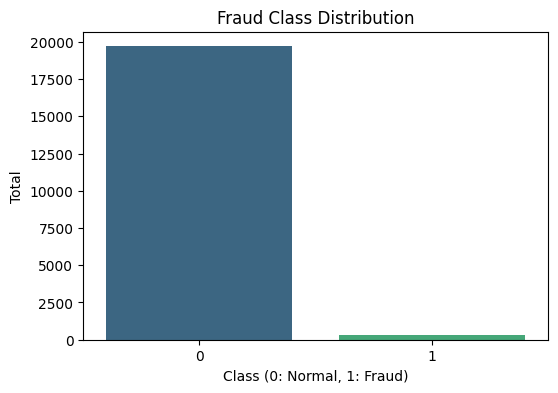

In [4]:
print("Dataset Overview")
df.info()

print("\n Missing Values")
print(df.isnull().sum())

print(f"Total duplicates: {df.duplicated().sum()}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Fraud_Flag', palette='viridis')
plt.title('Fraud Class Distribution')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Total')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
print(f"Data before preprocessing: {df.shape}")

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()

irrelevant_cols = ['Time', 'id', 'ID', 'Transaction_ID', 'Unnamed: 0']
cols_to_drop = [col for col in irrelevant_cols if col in df_clean.columns]

if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"Successfully dropped columns: {cols_to_drop}")

print(f"Data after preprocessing: {df_clean.shape}")
display(df_clean.head())

df_clean.to_csv('clean_dataset.csv', index=False)

Data before preprocessing: (20000, 16)
Successfully dropped columns: ['Transaction_ID']
Data after preprocessing: (20000, 15)


,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,77001,2024-05-01 20:43:12,114.35,Fuel,8154,Debit,ATM,USA,1,0,0,4.25,20,Mobile,0
1,31519,2025-01-31 13:10:05,107.65,Travel,2676,Debit,POS,USA,0,0,0,1.55,13,Mobile,0
2,68440,2025-02-16 02:48:18,61.47,Entertainment,5165,Debit,ATM,India,0,0,0,5.63,2,Terminal,0
3,17594,2024-01-22 13:11:42,162.72,Groceries,6241,Credit,Online,USA,0,0,1,1.78,13,Web,0
4,37921,2024-05-26 16:52:07,29.71,Travel,1866,Platinum,ATM,Australia,0,0,0,2.31,16,Mobile,0
